<a href="https://colab.research.google.com/github/Saiful-2/house-price-prediction/blob/main/notebooks/3_housing_statistical_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🟩 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 🟩 2. Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/ames_housing_cleaned.csv"

df = pd.read_csv(url)

df.shape

(2925, 80)

In [3]:
df.head()

,ms_subclass,ms_zoning,lot_frontage,lot_area,street,alley,lot_shape,land_contour,utilities,lot_config,land_slope,neighborhood,condition_1,condition_2,bldg_type,house_style,overall_qual,overall_cond,year_built,year_remodadd,roof_style,roof_matl,exterior_1st,exterior_2nd,mas_vnr_type,mas_vnr_area,exter_qual,exter_cond,foundation,bsmt_qual,bsmt_cond,bsmt_exposure,bsmtfin_type_1,bsmtfin_sf_1,bsmtfin_type_2,bsmtfin_sf_2,bsmt_unf_sf,total_bsmt_sf,heating,heating_qc,central_air,electrical,1st_flr_sf,2nd_flr_sf,low_qual_fin_sf,gr_liv_area,bsmt_full_bath,bsmt_half_bath,full_bath,half_bath,bedroom_abvgr,kitchen_abvgr,kitchen_qual,totrms_abvgrd,functional,fireplaces,fireplace_qu,garage_type,garage_yr_blt,garage_finish,garage_cars,garage_area,garage_qual,garage_cond,paved_drive,wood_deck_sf,open_porch_sf,enclosed_porch,3ssn_porch,screen_porch,pool_area,pool_qc,fence,misc_feature,misc_val,mo_sold,yr_sold,sale_type,sale_condition,saleprice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,Ex,NaN,Shed,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,BrkFace,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,Gd,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,Ex,MnPrv,Shed,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,Gd,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,Ex,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,BrkFace,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,Ex,NaN,Shed,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,Ex,MnPrv,Shed,0,3,2010,WD,Normal,189900


## 🟩 3. Separate Feature Types

In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

## 🎯 4. Descriptive Statistics

In [6]:
df[target].describe()

,saleprice
count,2925.000000
mean,180411.574701
std,78554.857286
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,625000.000000


### 📊 Distribution Plot

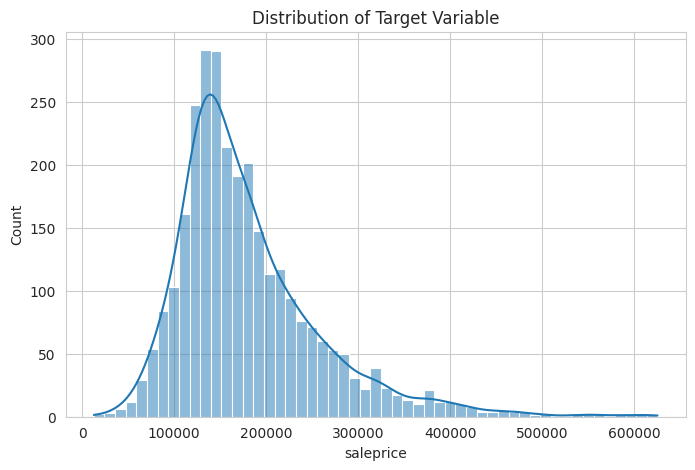

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df[target], kde=True)
plt.title("Distribution of Target Variable")
plt.show()

## 📐 5. Skewness & Kurtosis

In [8]:
skewness = df[target].skew()
kurtosis = df[target].kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: 1.5910724110509824
Kurtosis: 3.8395280893588817


### 💡 Interpretation:
Skewness > 0 → Right skewed
Kurtosis > 3 → Heavy tails

### 📊 Log Transformation

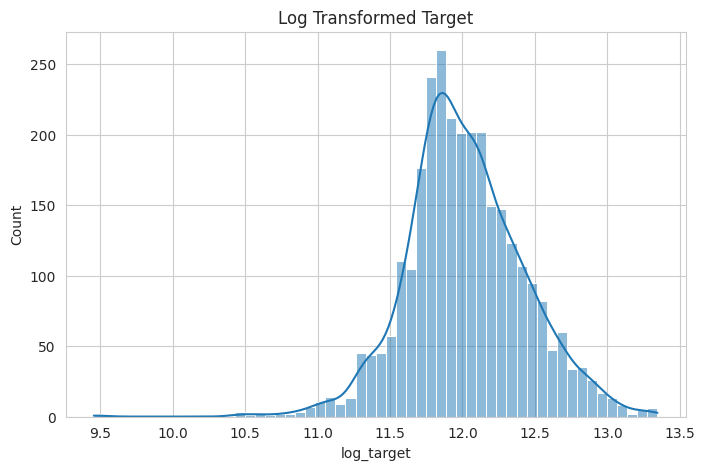

In [9]:
df["log_target"] = np.log1p(df[target])

plt.figure(figsize=(8,5))
sns.histplot(df["log_target"], kde=True)
plt.title("Log Transformed Target")
plt.show()

## 🧪 6. Normality Test
Shapiro-Wilk Test

In [10]:
sample = df[target].sample(500, random_state=42)

stat, p = stats.shapiro(sample)

print("Shapiro Test Statistic:", stat)
print("p-value:", p)

Shapiro Test Statistic: 0.8710692578404204
p-value: 6.404094612850058e-20


### 💡 Interpretation:
p < 0.05 → Not normal

### 🔹 Q-Q Plot

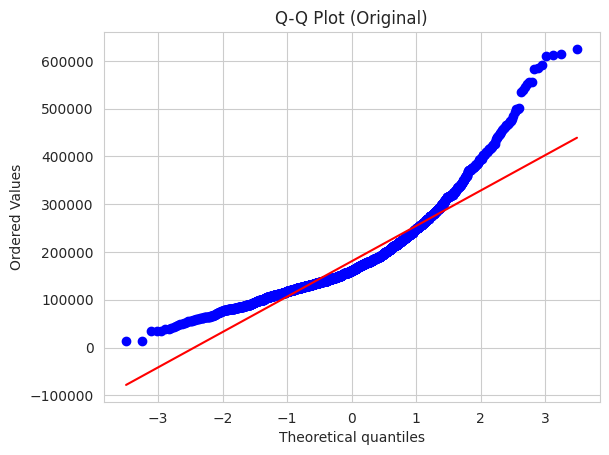

In [11]:
stats.probplot(df[target], dist="norm", plot=plt)
plt.title("Q-Q Plot (Original)")
plt.show()

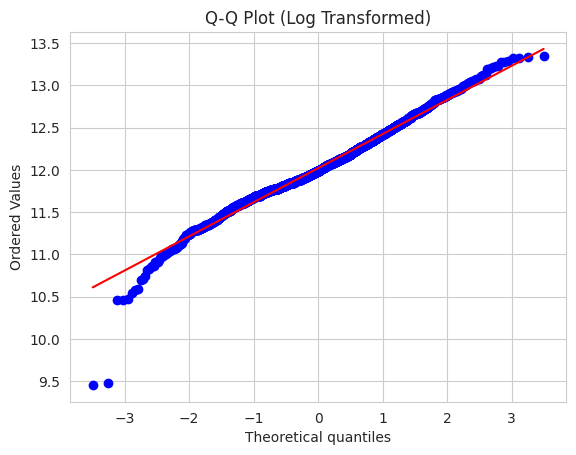

In [12]:
stats.probplot(df["log_target"], dist="norm", plot=plt)
plt.title("Q-Q Plot (Log Transformed)")
plt.show()

## 📊 7. Correlation Significance (Pearson Test)

In [13]:
results = []

for col in num_cols:
    if col != target:
        corr, p = stats.pearsonr(df[col], df[target])
        results.append((col, corr, p))

corr_df = pd.DataFrame(results, columns=["Feature", "Correlation", "p_value"])
corr_df.sort_values(by="Correlation", ascending=False).head(10)

,Feature,Correlation,p_value
3,overall_qual,0.805236,0.000000e+00
15,gr_liv_area,0.719463,0.000000e+00
11,total_bsmt_sf,0.658519,0.000000e+00
25,garage_cars,0.652480,0.000000e+00
26,garage_area,0.648301,0.000000e+00
12,1st_flr_sf,0.642902,0.000000e+00
5,year_built,0.565110,1.717400e-246
18,full_bath,0.544486,1.741356e-225
6,year_remodadd,0.540290,2.172730e-221
24,garage_yr_blt,0.515118,5.450058e-198


### 💡 Interpretation:
p < 0.05 → statistically significant

## 8. Spearman Correlation (Non-linear)

In [14]:
results_s = []

for col in num_cols:
    if col != target:
        corr, p = stats.spearmanr(df[col], df[target])
        results_s.append((col, corr, p))

spearman_df = pd.DataFrame(results_s, columns=["Feature", "Spearman_corr", "p_value"])
spearman_df.sort_values(by="Spearman_corr", ascending=False).head(10)

,Feature,Spearman_corr,p_value
3,overall_qual,0.809173,0.000000e+00
15,gr_liv_area,0.723374,0.000000e+00
25,garage_cars,0.701407,0.000000e+00
5,year_built,0.681306,0.000000e+00
26,garage_area,0.660550,0.000000e+00
18,full_bath,0.633426,0.000000e+00
24,garage_yr_blt,0.607816,4.834706e-295
11,total_bsmt_sf,0.605565,2.688838e-292
6,year_remodadd,0.602259,2.642872e-288
12,1st_flr_sf,0.581123,7.445211e-264


## 🧪 9. ANOVA (Categorical vs Target)

👉 Compare means across categories

In [15]:
anova_results = []

for col in cat_cols:
    groups = []

    for val in df[col].unique():
        groups.append(df[df[col] == val][target])

    if len(groups) > 1:
        stat, p = stats.f_oneway(*groups)
        anova_results.append((col, stat, p))

anova_df = pd.DataFrame(anova_results, columns=["Feature", "F_stat", "p_value"])
anova_df.sort_values(by="p_value").head(10)

/tmp/ipykernel_21959/380155246.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = stats.f_oneway(*groups)


,Feature,F_stat,p_value
8,neighborhood,147.196245,0.000000e+00
30,kitchen_qual,691.987065,0.000000e+00
21,bsmt_qual,773.283052,0.000000e+00
18,exter_qual,1039.221323,0.000000e+00
34,garage_finish,633.596162,2.669451e-229
20,foundation,232.747716,1.355323e-209
27,heating_qc,204.373196,9.936824e-155
33,garage_type,126.692983,1.030368e-121
23,bsmt_exposure,198.017700,6.680456e-117
15,exterior_1st,42.494556,2.007011e-113


### 💡 Interpretation:
p < 0.05 → category significantly affects price

## 📊 10. Variance Analysis

In [16]:
df[num_cols].var().sort_values(ascending=False).head(10)

,0
saleprice,6.170866e+09
lot_area,6.055951e+07
gr_liv_area,2.364621e+05
misc_val,2.230087e+05
bsmt_unf_sf,1.932038e+05
bsmtfin_sf_1,1.918083e+05
2nd_flr_sf,1.813414e+05
total_bsmt_sf,1.772737e+05
1st_flr_sf,1.418216e+05
garage_area,4.570169e+04


## 📉 11. Multicollinearity Check
🔹 Correlation Matrix (High Correlation)

In [17]:
corr_matrix = df[num_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [column for column in upper.columns if any(upper[column] > 0.8)]

high_corr

['totrms_abvgrd', 'garage_area', 'saleprice']

### 🔹 Variance Inflation Factor (VIF)

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[num_cols].drop(columns=[target])

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data.sort_values(by="VIF", ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
12,1st_flr_sf,inf
13,2nd_flr_sf,inf
14,low_qual_fin_sf,inf
15,gr_liv_area,inf
11,total_bsmt_sf,1.580435e+05
10,bsmt_unf_sf,6.279017e+04
8,bsmtfin_sf_1,4.766258e+04
35,yr_sold,2.300834e+04
6,year_remodadd,2.205244e+04
24,garage_yr_blt,2.069757e+04


### 💡 Interpretation:
VIF > 5 → moderate multicollinearity
VIF > 10 → serious issue

## 📊 12. Covariance Matrix

In [19]:
df[num_cols].cov().head()

,ms_subclass,lot_frontage,lot_area,overall_qual,overall_cond,year_built,year_remodadd,mas_vnr_area,bsmtfin_sf_1,bsmtfin_sf_2,bsmt_unf_sf,total_bsmt_sf,1st_flr_sf,2nd_flr_sf,low_qual_fin_sf,gr_liv_area,bsmt_full_bath,bsmt_half_bath,full_bath,half_bath,bedroom_abvgr,kitchen_abvgr,totrms_abvgrd,fireplaces,garage_yr_blt,garage_cars,garage_area,wood_deck_sf,open_porch_sf,enclosed_porch,3ssn_porch,screen_porch,pool_area,misc_val,mo_sold,yr_sold,saleprice
ms_subclass,1820.622423,-356.232790,-6.858199e+04,2.411656,-3.203476,47.615126,38.918722,40.018942,-1130.702824,-512.276298,-2439.857402,-4084.806112,-4104.985632,5557.859757,50.919852,1503.793977,0.323222,-0.021954,3.180865,3.781458,-0.692292,2.355829,2.237121,-1.369504,89.914219,-1.476932,-941.142043,-88.171641,-37.706748,-62.851262,-40.781269,-121.395727,-6.163566,-490.684782,0.094243,-1.015077,-2.912950e+05
lot_frontage,-356.232790,429.497331,5.505633e+04,5.340665,-1.511784,68.292358,34.913533,665.404873,1320.142630,149.832238,1022.120561,2493.683235,3065.124568,92.778310,6.182226,3164.085104,0.916483,-0.142564,1.827629,0.285053,3.790625,0.032900,9.997117,2.847425,32.129111,4.569609,1430.915515,250.026130,178.682652,20.530782,13.946604,86.679788,65.324186,92.529415,0.925662,-0.151194,5.577865e+05
lot_area,-68581.992464,55056.328355,6.055951e+07,908.975525,-283.860923,4012.359076,2579.239823,142839.255436,531824.374610,113287.615506,74197.304428,719090.008678,895798.376449,82016.917365,504.663499,978319.957313,474.733873,40.007081,520.886768,113.268798,890.007789,-32.332718,2434.316293,1243.966160,-3092.948764,1041.040672,330744.137740,147638.279625,42673.582835,12093.835173,3338.680250,25080.380236,16572.612202,141862.559531,120.951438,-223.190838,1.650836e+08
overall_qual,2.411656,5.340665,9.089755e+02,1.968277,-0.146529,25.313902,16.668119,102.214430,165.180868,-9.498608,166.501295,322.073575,248.650483,139.819813,-3.155156,385.315140,0.121080,-0.016625,0.401260,0.186853,0.071735,-0.048039,0.811894,0.350545,18.824026,0.637345,167.568497,44.254729,27.029055,-12.568106,0.665525,3.406092,0.159891,-18.258452,0.122120,-0.034608,8.874407e+04
overall_cond,-3.203476,-1.511784,-2.838609e+02,-0.146529,1.237127,-12.396543,1.122033,-26.049530,-23.652988,7.688983,-66.936645,-82.825007,-66.657836,3.355909,0.470174,-62.831753,-0.024696,0.022987,-0.131441,-0.048934,-0.005715,-0.020619,-0.153549,-0.021999,-8.418672,-0.153111,-36.401789,2.966610,-4.973706,5.088919,1.225949,2.741285,-0.467205,24.721557,-0.020665,0.045449,-9.025367e+03


## 📉 13. Residual Concept

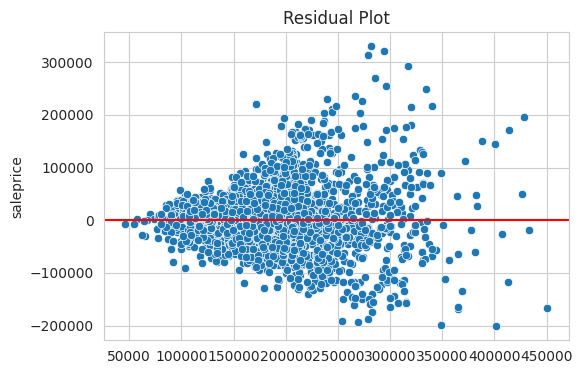

In [20]:
# Simple regression example
from sklearn.linear_model import LinearRegression

X = df[["gr_liv_area"]] if "gr_liv_area" in df.columns else df[[num_cols[1]]]
y = df[target]

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)
residuals = y - pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.show()

## 🧾 16. Final Statistical Insights
📌 Key Statistical Findings:
1. Target variable is right-skewed

2. Log transformation improves normality

3. Several features show strong correlation with target

4. Pearson & Spearman confirm relationships

5. ANOVA shows categorical features significantly affect price

6. Multicollinearity exists among some variables

7. VIF analysis identifies redundant features

8. Residuals indicate non-linearity in raw data